<a href="https://colab.research.google.com/github/nightlurkr/FinalProjectAI-CekFresh/blob/main/fp_ai_kel8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ryanadya","key":"c63fd2418a030d2fd484e87843e76a1b"}'}

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')

os.chmod('/root/.kaggle/kaggle.json', 600)

print("Kaggle API siap digunakan!")

Kaggle API siap digunakan!


In [ ]:
import os

# Download dataset 1: sriramr (pisang & jeruk)
!kaggle datasets download -d sriramr/fruits-fresh-and-rotten-for-classification -p /content/datasets/sriramr

# Download dataset 2: raghavrpotdar (tomat)
!kaggle datasets download -d raghavrpotdar/fresh-and-stale-images-of-fruits-and-vegetables -p /content/datasets/raghavrpotdar

# Download dataset 3: fruits-360 (tomat segar berkualitas)
# Coba beberapa nama dataset alternatif
os.makedirs('/content/datasets/fruits360', exist_ok=True)
result = os.system('kaggle datasets download -d moltean/fruits-360 -p /content/datasets/fruits360 2>/tmp/f360_err.txt')
if result != 0:
    result = os.system('kaggle datasets download -d moltean/fruits-360-dataset-with-20-categories -p /content/datasets/fruits360 2>>/tmp/f360_err.txt')
if result != 0:
    result = os.system('kaggle datasets download -d chrisfilo/fruit-recognition -p /content/datasets/fruits360 2>>/tmp/f360_err.txt')

if result == 0:
    print("✅ fruits-360 berhasil didownload")
else:
    print("⚠️  fruits-360 gagal didownload — akan fallback ke raghavrpotdar fresh_tomato")
    with open('/tmp/f360_err.txt') as f:
        print(f.read()[:300])

print("\nDownload selesai!")


Dataset URL: https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification
License(s): unknown
100% 3.58G/3.58G [03:31<00:00, 18.2MB/s]

Dataset URL: https://www.kaggle.com/datasets/raghavrpotdar/fresh-and-stale-images-of-fruits-and-vegetables
License(s): CC0-1.0
100% 1.41G/1.41G [01:26<00:00, 17.5MB/s]

✅ fruits-360 berhasil didownload

Download selesai!


In [ ]:
import zipfile, os, glob

with zipfile.ZipFile('/content/datasets/sriramr/fruits-fresh-and-rotten-for-classification.zip', 'r') as z:
    z.extractall('/content/datasets/sriramr/')

with zipfile.ZipFile('/content/datasets/raghavrpotdar/fresh-and-stale-images-of-fruits-and-vegetables.zip', 'r') as z:
    z.extractall('/content/datasets/raghavrpotdar/')

# fruits-360 — ekstrak jika berhasil didownload
fruits360_dir = '/content/datasets/fruits360'
zip_files = glob.glob(f'{fruits360_dir}/*.zip')

if zip_files:
    fruits360_zip = zip_files[0]
    print(f"Mengekstrak fruits-360: {fruits360_zip}")
    try:
        with zipfile.ZipFile(fruits360_zip, 'r') as z:
            members = [m for m in z.namelist()
                       if '/Training/' in m or '/training/' in m or m.startswith('Training/')]
            if members:
                z.extractall(fruits360_dir, members)
                print(f"✅ fruits-360 diekstrak ({len(members)} files)")
            else:
                z.extractall(fruits360_dir)
                print(f"✅ fruits-360 diekstrak (semua files)")
    except Exception as e:
        print(f"⚠️  Gagal ekstrak fruits-360: {e}")
else:
    print("⚠️  fruits-360 tidak tersedia, freshtomato akan pakai raghavrpotdar")

print("\nEkstrak selesai!")


Mengekstrak fruits-360: /content/datasets/fruits360/fruit-recognition.zip
✅ fruits-360 diekstrak (semua files)

Ekstrak selesai!


In [ ]:
# Melihat isi folder hasil ekstrak untuk memastikan strukturnya benar
for dataset in ['sriramr', 'raghavrpotdar']:
    print(f"\n=== Struktur {dataset} ===")
    for root, dirs, files in os.walk(f'/content/datasets/{dataset}'):
        level = root.replace(f'/content/datasets/{dataset}', '').count(os.sep)
        if level < 3:
            indent = ' ' * 2 * level
            print(f'{indent}{os.path.basename(root)}/')


=== Struktur sriramr ===
sriramr/
  dataset/
    test/
    train/
    dataset/

=== Struktur raghavrpotdar ===
raghavrpotdar/
  fresh_orange/
  stale_tomato/
  fresh_tomato/
  fresh_apple/
  stale_banana/
  stale_orange/
  stale_bitter_gourd/
  stale_capsicum/
  fresh_capsicum/
  fresh_bitter_gourd/
  fresh_banana/
  stale_apple/


### EDA (Exploratory Data Analysis)

Melihat struktur lengkap kedua dataset

In [ ]:
print("=== ISI DATASET SRIRAMR ===")
for item in sorted(os.listdir('/content/datasets/sriramr')):
    print(f"  {item}")

print("\n=== ISI DATASET RAGHAVRPOTDAR ===")
for item in sorted(os.listdir('/content/datasets/raghavrpotdar')):
    print(f"  {item}")

=== ISI DATASET SRIRAMR ===
  dataset
  fruits-fresh-and-rotten-for-classification.zip

=== ISI DATASET RAGHAVRPOTDAR ===
  ImageLabels.txt
  fresh-and-stale-images-of-fruits-and-vegetables.zip
  fresh_apple
  fresh_banana
  fresh_bitter_gourd
  fresh_capsicum
  fresh_orange
  fresh_tomato
  stale_apple
  stale_banana
  stale_bitter_gourd
  stale_capsicum
  stale_orange
  stale_tomato


untuk Raghavpotdae langsung terlihat struktur foldernya tapi untuk dataset siramr masih ada didalam folder `dataset` jadi selanjutnya mencoba untuk melihat isi dari folder dataset di sriramr.

In [ ]:
print("=== ISI FOLDER DATASET/SRIRAMR ===")
for item in sorted(os.listdir('/content/datasets/sriramr/dataset')):
    print(f"  {item}")

=== ISI FOLDER DATASET/SRIRAMR ===
  dataset
  test
  train


masih ada subfolder lagi dan terlihat bahwa sriramr strukturnya `dataset/dataset/train` dan `dataset/dataset/test` selanjutnya melihat satu level lagi untuk melihat isi dari folder train dan test di sriramr.

In [ ]:
print("=== ISI FOLDER TRAIN ===")
for item in sorted(os.listdir('/content/datasets/sriramr/dataset/dataset/train')):
    print(f"  {item}")

print("\n=== ISI FOLDER TEST ===")
for item in sorted(os.listdir('/content/datasets/sriramr/dataset/dataset/test')):
    print(f"  {item}")

=== ISI FOLDER TRAIN ===
  freshapples
  freshbanana
  freshoranges
  rottenapples
  rottenbanana
  rottenoranges

=== ISI FOLDER TEST ===
  freshapples
  freshbanana
  freshoranges
  rottenapples
  rottenbanana
  rottenoranges


#### **Menghitung jumlah gambar per kelas di kedua dataset**

ini untuk mendeteksi jika ada class imbalance (ketidakseimbangan jumlah data antar kelas) sebelum proses training.

In [ ]:
sriramr_base_train = '/content/datasets/sriramr/dataset/dataset/train'
sriramr_base_test  = '/content/datasets/sriramr/dataset/dataset/test'
raghavrpotdar_base = '/content/datasets/raghavrpotdar'

# Folder yang relevan dari masing-masing dataset
sriramr_train_folders = [
    'freshbanana', 'rottenbanana',
    'freshoranges', 'rottenoranges'
]
sriramr_test_folders = [
    'freshbanana', 'rottenbanana',
    'freshoranges', 'rottenoranges'
]
raghavrpotdar_folders = [
    'fresh_tomato', 'stale_tomato'
]

print("=== JUMLAH GAMBAR SRIRAMR (Train) ===")
for folder in sriramr_train_folders:
    path = os.path.join(sriramr_base_train, folder)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {folder}: {count} gambar")

print("\n=== JUMLAH GAMBAR SRIRAMR (Test) ===")
for folder in sriramr_test_folders:
    path = os.path.join(sriramr_base_test, folder)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {folder}: {count} gambar")

print("\n=== JUMLAH GAMBAR RAGHAVRPOTDAR (Tomat) ===")
for folder in raghavrpotdar_folders:
    path = os.path.join(raghavrpotdar_base, folder)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {folder}: {count} gambar")


=== JUMLAH GAMBAR SRIRAMR (Train) ===
  freshbanana: 1581 gambar
  rottenbanana: 2224 gambar
  freshoranges: 1466 gambar
  rottenoranges: 1595 gambar

=== JUMLAH GAMBAR SRIRAMR (Test) ===
  freshbanana: 381 gambar
  rottenbanana: 530 gambar
  freshoranges: 388 gambar
  rottenoranges: 403 gambar

=== JUMLAH GAMBAR RAGHAVRPOTDAR (Tomat) ===
  fresh_tomato: 981 gambar
  stale_tomato: 982 gambar


Hasil:

Pisang (sriramr):

- Train: fresh 1.581 + rotten 2.224 = 3.805 gambar
- Test: fresh 381 + rotten 530 = 911 gambar
- Total: fresh 1.581 & rotten 2.224, rasio: 71% **(kurang seimbang**)
- Data ini sedikit tidak seimbang karena selisihnya 643 gambar dimana rotten lebih banyak ±40% dari fresh

Jeruk (sriramr):

- Train: fresh 1.466 + rotten 1.595 = 3.061 gambar
- Test: fresh 388 + rotten 403 = 791 gambar
- Total: fresh 1.466 & rotten 1.595, rasio: 91,9% **(hampir seimbang)**

Tomat (raghavrpotdar):

- fresh 981 + stale 982 = 1.963 gambar
- rasio: 99,9% **(sangat seimbang)**

Total keseluruhan: ±10.531 gambar dimana ini adalah jumlah yang sangat cukup untuk fine-tuning MobileNetV2. Lalu karna sriramr sudah punya pembagian train dan test sendiri, sedangkan raghavrpotdar belum maka selanjutnya ini akan ditangani saat split data nanti.


#### **Visualisai Sample Gambar per Kelas**

 ini menampilkan satu gambar secara acak dari masing-masing kelas (fresh banana, rotten banana, fresh orange, rotten orange, fresh tomato, rotten tomato) dalam satu grid 2×3. Yang mana ini bertujuan untuk memverifikasi secara visual bahwa gambar bisa terbaca dengan benar, tidak korup, dan kualitasnya layak untuk digunakan dalam training.

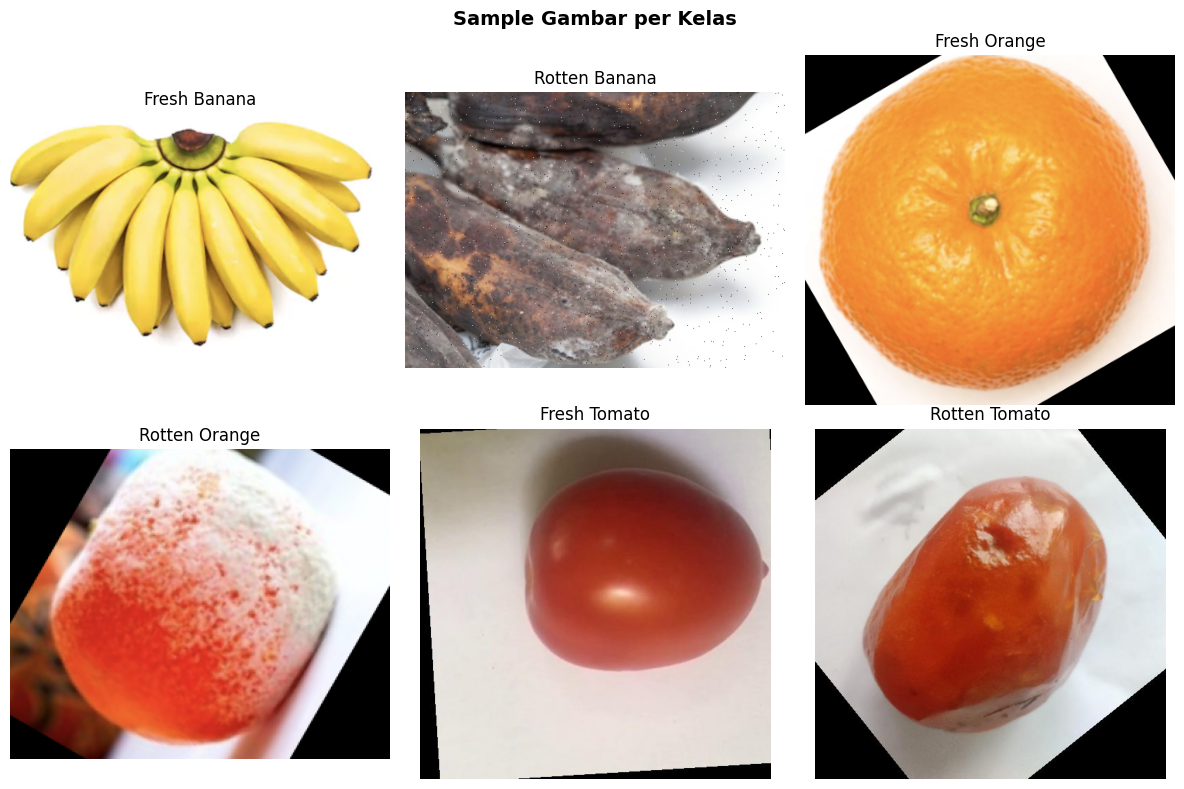

Tampilan sample gambar selesai!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

classes = {
    'Fresh Banana'  : '/content/datasets/sriramr/dataset/dataset/train/freshbanana',
    'Rotten Banana' : '/content/datasets/sriramr/dataset/dataset/train/rottenbanana',
    'Fresh Orange'  : '/content/datasets/sriramr/dataset/dataset/train/freshoranges',
    'Rotten Orange' : '/content/datasets/sriramr/dataset/dataset/train/rottenoranges',
    'Fresh Tomato'  : '/content/datasets/raghavrpotdar/fresh_tomato',
    'Rotten Tomato' : '/content/datasets/raghavrpotdar/stale_tomato',
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, (label, path) in enumerate(classes.items()):
    images = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random_img = random.choice(images)

    img = mpimg.imread(os.path.join(path, random_img))
    axes[idx].imshow(img)
    axes[idx].set_title(label, fontsize=12)
    axes[idx].axis('off')

plt.suptitle('Sample Gambar per Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Tampilan sample gambar selesai!")

### Filter, Seleksi & Standarisasi Label — Multiclass

Karena kita sekarang memakai **6 kelas terpisah** (freshbanana, rottenbanana, freshorange, rottenorange, freshtomato, rottentomato), setiap kelas mendapat folder sendiri. Ini memungkinkan model tidak hanya mendeteksi segar/busuk tapi juga **jenis buahnya**.


In [ ]:
import os
import shutil

base_output = '/content/datasets/final'

# 6 kelas multiclass
CLASSES = ['freshbanana', 'rottenbanana', 'freshorange', 'rottenorange', 'freshtomato', 'rottentomato']

for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        os.makedirs(f'{base_output}/{split}/{cls}', exist_ok=True)

print("Struktur folder final (multiclass) berhasil dibuat!")
print("\nStruktur yang dibuat:")
for split in ['train', 'val', 'test']:
    print(f"  final/{split}/")
    for cls in CLASSES:
        print(f"    {cls}/")


Struktur folder final (multiclass) berhasil dibuat!

Struktur yang dibuat:
  final/train/
    freshbanana/
    rottenbanana/
    freshorange/
    rottenorange/
    freshtomato/
    rottentomato/
  final/val/
    freshbanana/
    rottenbanana/
    freshorange/
    rottenorange/
    freshtomato/
    rottentomato/
  final/test/
    freshbanana/
    rottenbanana/
    freshorange/
    rottenorange/
    freshtomato/
    rottentomato/


#### **Mengcopy gambar ke folder final (6 kelas terpisah):**

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# RESET: Hapus folder organized untuk memastikan training bersih
# Wajib dijalankan setiap kali training ulang!
# Tanpa ini, split data akan duplikat antar sesi → data leakage!
# ═══════════════════════════════════════════════════════════════════
import shutil

if os.path.exists(base_output):
    shutil.rmtree(base_output)
    print(f"🗑️  Folder '{base_output}' dihapus (reset bersih)")
else:
    print(f"✅  Folder belum ada, siap membuat dari scratch")

# Buat ulang semua subfolder kelas
CLASSES = ['freshbanana','rottenbanana','freshorange','rottenorange','freshtomato','rottentomato']
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        os.makedirs(f'{base_output}/{split}/{cls}', exist_ok=True)

print("✅  Struktur folder bersih berhasil dibuat!")


🗑️  Folder '/content/datasets/final' dihapus (reset bersih)
✅  Struktur folder bersih berhasil dibuat!


In [ ]:
import uuid, shutil, os

def copy_images(src_folder, dst_folder, max_images=None):
    images = [f for f in os.listdir(src_folder)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if max_images:
        import random; random.seed(42); images = random.sample(images, min(max_images, len(images)))
    for img_name in images:
        src_path = os.path.join(src_folder, img_name)
        new_name = f"{uuid.uuid4().hex}.jpg"
        dst_path = os.path.join(dst_folder, new_name)
        shutil.copy2(src_path, dst_path)
    return len(images)

sriramr_train    = '/content/datasets/sriramr/dataset/dataset/train'
sriramr_test     = '/content/datasets/sriramr/dataset/dataset/test'
raghavrpotdar_base = '/content/datasets/raghavrpotdar'

# ── SRIRAMR Train ──────────────────────────────────────────────────
mapping_sriramr_train = {
    'freshbanana'   : 'freshbanana',
    'rottenbanana'  : 'rottenbanana',
    'freshoranges'  : 'freshorange',
    'rottenoranges' : 'rottenorange',
}
print("=== Menyalin SRIRAMR (Train) ===")
for folder, cls in mapping_sriramr_train.items():
    src = os.path.join(sriramr_train, folder)
    dst = os.path.join(base_output, 'train', cls)
    count = copy_images(src, dst)
    print(f"  {folder} → train/{cls}: {count} gambar")

# ── SRIRAMR Test ──────────────────────────────────────────────────
mapping_sriramr_test = {
    'freshbanana'   : 'freshbanana',
    'rottenbanana'  : 'rottenbanana',
    'freshoranges'  : 'freshorange',
    'rottenoranges' : 'rottenorange',
}
print("\n=== Menyalin SRIRAMR (Test) ===")
for folder, cls in mapping_sriramr_test.items():
    src = os.path.join(sriramr_test, folder)
    dst = os.path.join(base_output, 'test', cls)
    count = copy_images(src, dst)
    print(f"  {folder} → test/{cls}: {count} gambar")

# ── RAGHAVRPOTDAR: banana & orange tambahan ──────────────────────
print("\n=== Menyalin RAGHAVRPOTDAR (pisang & jeruk tambahan) ===")
raghavrpotdar_extras = {
    'fresh_banana'  : 'freshbanana',
    'stale_banana'  : 'rottenbanana',
    'fresh_orange'  : 'freshorange',
    'stale_orange'  : 'rottenorange',
}
for folder, cls in raghavrpotdar_extras.items():
    src = os.path.join(raghavrpotdar_base, folder)
    if os.path.exists(src):
        dst = os.path.join(base_output, 'train', cls)
        count = copy_images(src, dst)
        print(f"  {folder} → train/{cls}: {count} gambar")
    else:
        print(f"  ⚠️  {folder} tidak ditemukan, skip")

# ── RAGHAVRPOTDAR: stale_tomato (tomat BUSUK) ────────────────────
print("\n=== Menyalin RAGHAVRPOTDAR (tomat busuk) ===")
src_rotten = os.path.join(raghavrpotdar_base, 'stale_tomato')
dst_rotten = os.path.join(base_output, 'train', 'rottentomato')
if os.path.exists(src_rotten):
    count = copy_images(src_rotten, dst_rotten)
    print(f"  stale_tomato → train/rottentomato: {count} gambar")

# ── FRUITS-360: fresh tomato (KUALITAS TINGGI, background putih) ─
print("\n=== Menyalin FRUITS-360 (tomat segar, kualitas tinggi) ===")
# fruits-360 punya beberapa subfolder Tomato (berbagai variety)
fruits360_base = '/content/datasets/fruits360'
# Cari folder Training
training_folder = None
for root, dirs, files in os.walk(fruits360_base):
    if os.path.basename(root).lower() == 'training':
        training_folder = root
        break

if training_folder:
    tomato_folders = [d for d in os.listdir(training_folder)
                      if 'tomato' in d.lower() and 'heart' not in d.lower()]
    print(f"  Folder tomat ditemukan: {tomato_folders}")
    dst_fresh = os.path.join(base_output, 'train', 'freshtomato')
    total = 0
    for tfolder in tomato_folders:
        src = os.path.join(training_folder, tfolder)
        count = copy_images(src, dst_fresh, max_images=300)  # max 300 per variety
        total += count
        print(f"  {tfolder}: {count} gambar")
    print(f"  Total freshtomato dari fruits-360: {total} gambar")
else:
    # Fallback ke raghavrpotdar fresh_tomato
    print("  ⚠️  fruits-360 Training folder tidak ditemukan, fallback ke raghavrpotdar")
    src = os.path.join(raghavrpotdar_base, 'fresh_tomato')
    dst = os.path.join(base_output, 'train', 'freshtomato')
    count = copy_images(src, dst)
    print(f"  fresh_tomato (raghavrpotdar) → train/freshtomato: {count} gambar")

print("\n✅ Semua gambar berhasil disalin!")


=== Menyalin SRIRAMR (Train) ===
  freshbanana → train/freshbanana: 1581 gambar
  rottenbanana → train/rottenbanana: 2224 gambar
  freshoranges → train/freshorange: 1466 gambar
  rottenoranges → train/rottenorange: 1595 gambar

=== Menyalin SRIRAMR (Test) ===
  freshbanana → test/freshbanana: 381 gambar
  rottenbanana → test/rottenbanana: 530 gambar
  freshoranges → test/freshorange: 388 gambar
  rottenoranges → test/rottenorange: 403 gambar

=== Menyalin RAGHAVRPOTDAR (pisang & jeruk tambahan) ===
  fresh_banana → train/freshbanana: 1581 gambar
  stale_banana → train/rottenbanana: 1467 gambar
  fresh_orange → train/freshorange: 1466 gambar
  stale_orange → train/rottenorange: 1595 gambar

=== Menyalin RAGHAVRPOTDAR (tomat busuk) ===
  stale_tomato → train/rottentomato: 982 gambar

=== Menyalin FRUITS-360 (tomat segar, kualitas tinggi) ===
  ⚠️  fruits-360 Training folder tidak ditemukan, fallback ke raghavrpotdar
  fresh_tomato (raghavrpotdar) → train/freshtomato: 981 gambar

✅ Semua 

Setiap buah sekarang punya folder kelas sendiri — 6 total:
- **freshbanana / rottenbanana** (dari sriramr)
- **freshorange / rottenorange** (dari sriramr, folder nama aslinya `freshoranges/rottenoranges` di-rename)
- **freshtomato / rottentomato** (dari raghavrpotdar, `stale` → `rotten`)

Dataset raghavrpotdar (tomat) belum punya split test, jadi semua tomat masuk ke `train/` dulu dan akan di-split manual di langkah berikutnya.


#### **Mengecek Distribusi Gambar Setelah Proses Copy sebelumnya**

In [ ]:
print("=== DISTRIBUSI FOLDER FINAL (setelah copy) ===")
total = 0
for split in ['train', 'val', 'test']:
    print(f"\n{split}/")
    split_total = 0
    for cls in CLASSES:
        path = f'{base_output}/{split}/{cls}'
        count = len([f for f in os.listdir(path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {cls}: {count} gambar")
        total += count
        split_total += count
    print(f"  Subtotal: {split_total} gambar")

print(f"\nTotal keseluruhan: {total} gambar")
print("(val masih kosong — akan diisi saat split berikutnya)")


=== DISTRIBUSI FOLDER FINAL (setelah copy) ===

train/
  freshbanana: 3162 gambar
  rottenbanana: 3691 gambar
  freshorange: 2932 gambar
  rottenorange: 3190 gambar
  freshtomato: 981 gambar
  rottentomato: 982 gambar
  Subtotal: 14938 gambar

val/
  freshbanana: 0 gambar
  rottenbanana: 0 gambar
  freshorange: 0 gambar
  rottenorange: 0 gambar
  freshtomato: 0 gambar
  rottentomato: 0 gambar
  Subtotal: 0 gambar

test/
  freshbanana: 381 gambar
  rottenbanana: 530 gambar
  freshorange: 388 gambar
  rottenorange: 403 gambar
  freshtomato: 0 gambar
  rottentomato: 0 gambar
  Subtotal: 1702 gambar

Total keseluruhan: 16640 gambar
(val masih kosong — akan diisi saat split berikutnya)


Terlihat bahwa `val/` masih kosong dan tomat hanya ada di `train/`. Langkah berikutnya adalah split 15% dari masing-masing kelas di `train/` ke `val/`, dan juga membuat test set untuk tomat (karena raghavrpotdar tidak punya split test bawaan).


#### **Split Data dan Memindahkan Gambar Tomat**

In [ ]:
# ── GUARD: Pastikan cell ini hanya jalan sekali per sesi ──────────────
val_check = f'{base_output}/val/freshbanana'
if not os.path.exists(val_check) or len(os.listdir(val_check)) == 0:
    pass  # Lanjutkan split
else:
    print("❌ ERROR: Folder val sudah berisi data!")
    print("   Ini berarti cell 'RESET' di atas belum dijalankan.")
    print("   Jalankan ulang dari cell RESET untuk menghindari data leakage!")
    raise RuntimeError("Val sudah berisi data — jalankan RESET terlebih dahulu!")

import random
import shutil

def move_images_pct(src_folder, dst_folder, pct=0.15, seed=42):
    images = [f for f in os.listdir(src_folder)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.seed(seed)
    n = int(len(images) * pct)
    selected = random.sample(images, n)
    for img_name in selected:
        shutil.move(os.path.join(src_folder, img_name),
                    os.path.join(dst_folder, img_name))
    return n

print("=== Split 15% dari setiap kelas → Val ===")
for cls in CLASSES:
    n = move_images_pct(
        f'{base_output}/train/{cls}',
        f'{base_output}/val/{cls}',
        pct=0.15
    )
    print(f"  {cls}: {n} gambar dipindah ke val/")

# Tomat tidak punya test split bawaan → ambil 15% dari train untuk test
print("\n=== Split 15% tomat dari Train → Test ===")
for cls in ['freshtomato', 'rottentomato']:
    n = move_images_pct(
        f'{base_output}/train/{cls}',
        f'{base_output}/test/{cls}',
        pct=0.15
    )
    print(f"  {cls}: {n} gambar dipindah ke test/")

print("\nSplit selesai!")


=== Split 15% dari setiap kelas → Val ===
  freshbanana: 474 gambar dipindah ke val/
  rottenbanana: 553 gambar dipindah ke val/
  freshorange: 439 gambar dipindah ke val/
  rottenorange: 478 gambar dipindah ke val/
  freshtomato: 147 gambar dipindah ke val/
  rottentomato: 147 gambar dipindah ke val/

=== Split 15% tomat dari Train → Test ===
  freshtomato: 125 gambar dipindah ke test/
  rottentomato: 125 gambar dipindah ke test/

Split selesai!


Split dilakukan **per kelas** agar distribusi tiap kelas tetap proporsional di semua split. 15% dari tiap kelas di `train/` dipindah ke `val/`, dan untuk tomat 15% tambahan dipindah ke `test/` (karena tidak ada split bawaan).


#### **Mengecek Distribusi Final Dataset**

In [ ]:
print("=== DISTRIBUSI FINAL DATASET (6 Kelas) ===")
grand_total = 0
for split in ['train', 'val', 'test']:
    print(f"\n{split}/")
    split_total = 0
    for cls in CLASSES:
        path = f'{base_output}/{split}/{cls}'
        count = len([f for f in os.listdir(path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {cls}: {count} gambar")
        grand_total += count
        split_total += count
    print(f"  Subtotal: {split_total} gambar")

print(f"\nGrand total: {grand_total} gambar")


=== DISTRIBUSI FINAL DATASET (6 Kelas) ===

train/
  freshbanana: 2688 gambar
  rottenbanana: 3138 gambar
  freshorange: 2493 gambar
  rottenorange: 2712 gambar
  freshtomato: 709 gambar
  rottentomato: 710 gambar
  Subtotal: 12450 gambar

val/
  freshbanana: 474 gambar
  rottenbanana: 553 gambar
  freshorange: 439 gambar
  rottenorange: 478 gambar
  freshtomato: 147 gambar
  rottentomato: 147 gambar
  Subtotal: 2238 gambar

test/
  freshbanana: 381 gambar
  rottenbanana: 530 gambar
  freshorange: 388 gambar
  rottenorange: 403 gambar
  freshtomato: 125 gambar
  rottentomato: 125 gambar
  Subtotal: 1952 gambar

Grand total: 16640 gambar


Dataset final terdiri dari **6 kelas** yang dibagi ke tiga split (train/val/test). Model akan belajar mengenali jenis buah **sekaligus** kondisi kesegarannya dalam satu prediksi.


### Preprocessing

#### **Resize, Normalisasi & Augmentasi**

- Resize → MobileNetV2 hanya menerima input gambar ukuran 224×224 dan gambar dari dataset yang ada itu punya ukuran yang berbeda-beda, jadi harus diseragamkan
- Normalisasi → pixel value asli gambar berkisar 0–255, jadi akan diubah ke 0–1 agar model lebih mudah dan cepat belajar
- Augmentasi → khusus data train, akan ditambah variasi gambar secara artifisial (flip, rotasi, brightness) agar model lebih robust dan tidak overfitting

#### **Konfigurasi ImageDataGenerator**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as efficientnet_preprocess

# EfficientNetV2S memerlukan input di range [-1, 1]
# Gunakan preprocessing_function bukan rescale=1./255 (itu untuk MobileNetV2)

train_datagen = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess,
    horizontal_flip=True,
    rotation_range=15,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess
)

print("✅ ImageDataGenerator (EfficientNetV2S preprocessing [-1,1]) berhasil dikonfigurasi!")


✅ ImageDataGenerator (EfficientNetV2S preprocessing [-1,1]) berhasil dikonfigurasi!


- **train_datagen** (untuk training) selain normalisasi pixel ke rentang 0–1, juga menerapkan augmentasi data: flip horizontal, rotasi ±15°, variasi kecerahan 80–120%, dan zoom 10%. Augmentasi ini membuat model lebih robust dengan melihat variasi gambar yang lebih beragam.
- **val_test_datagen** (untuk validasi & test) hanya normalisasi saja, tanpa augmentasi. Ini penting agar evaluasi dilakukan pada kondisi gambar yang natural/asli.

#### **Load dataset menggunakan generator**

In [ ]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(
    f'{base_output}/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # multiclass
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    f'{base_output}/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

test_generator = val_test_datagen.flow_from_directory(
    f'{base_output}/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

print(f"Class indices: {train_generator.class_indices}")
print(f"Jumlah kelas : {train_generator.num_classes}")
for name, idx in sorted(train_generator.class_indices.items(), key=lambda x: x[1]):
    print(f"  {idx}: {name}")


Found 12450 images belonging to 6 classes.
Found 2238 images belonging to 6 classes.
Found 1952 images belonging to 6 classes.
Class indices: {'freshbanana': 0, 'freshorange': 1, 'freshtomato': 2, 'rottenbanana': 3, 'rottenorange': 4, 'rottentomato': 5}
Jumlah kelas : 6
  0: freshbanana
  1: freshorange
  2: freshtomato
  3: rottenbanana
  4: rottenorange
  5: rottentomato


`class_mode='categorical'` digunakan karena kita punya 6 kelas. Generator akan menghasilkan label one-hot encoded (misal: `[0,0,1,0,0,0]` untuk kelas ke-2). Urutan kelas diurutkan alfabetis oleh Keras.


#### **Hasil Preprocessing Secara Visual**

=== VERIFIKASI PREPROCESSING ===
Shape images: (32, 224, 224, 3)  (batch x 224 x 224 x 3)
Shape labels: (32, 6)  (batch x 6, one-hot)
Pixel min: 0.0000  max: 255.0000

Distribusi label dalam batch ini:
  0 (freshbanana): 12 gambar
  1 (freshorange): 5 gambar
  2 (freshtomato): 5 gambar
  3 (rottenbanana): 3 gambar
  4 (rottenorange): 7 gambar
  5 (rottentomato): 0 gambar


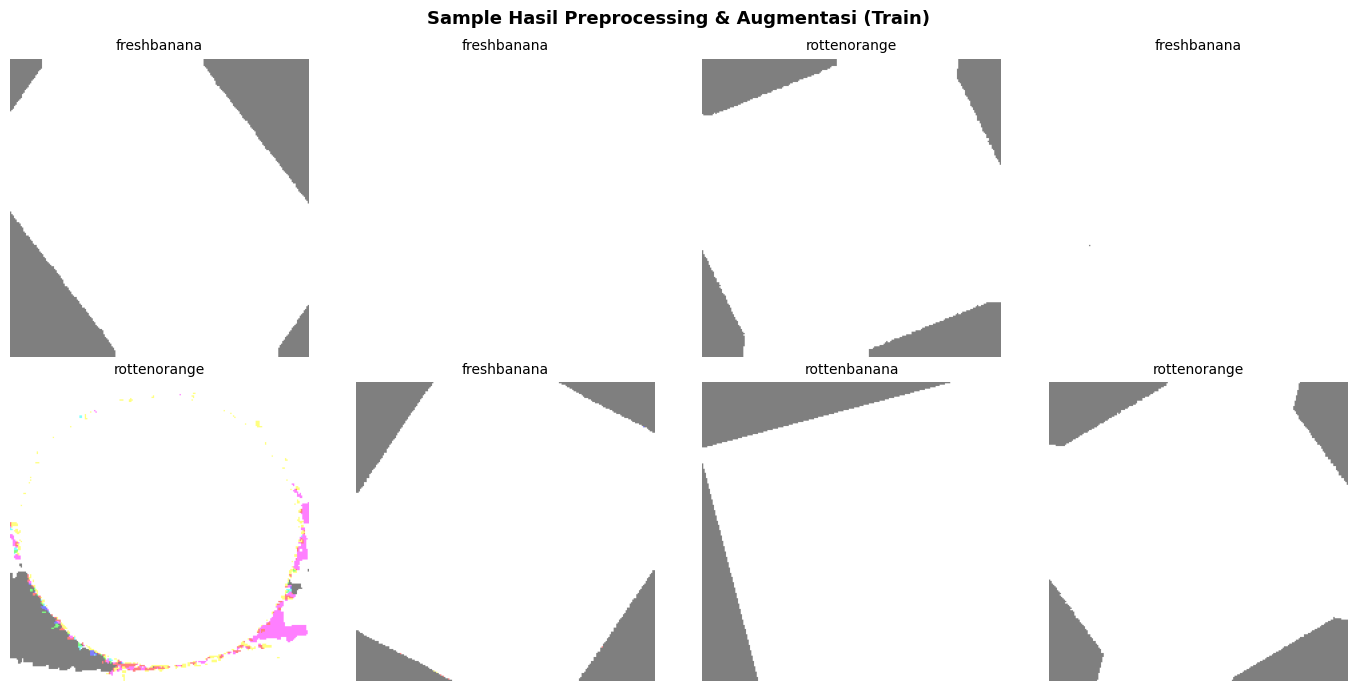

In [ ]:
import numpy as np

images, labels = next(train_generator)

idx_to_class = {v: k for k, v in train_generator.class_indices.items()}

print("=== VERIFIKASI PREPROCESSING ===")
print(f"Shape images: {images.shape}  (batch x 224 x 224 x 3)")
print(f"Shape labels: {labels.shape}  (batch x 6, one-hot)")
print(f"Pixel min: {images.min():.4f}  max: {images.max():.4f}")
print(f"\nDistribusi label dalam batch ini:")
label_ids = np.argmax(labels, axis=1)
for i in range(6):
    count = (label_ids == i).sum()
    print(f"  {i} ({idx_to_class[i]}): {count} gambar")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
for i in range(8):
    img_display = np.clip((images[i] + 1.0) / 2.0, 0, 1)  # denormalize [-1,1] → [0,1] for display
    axes[i].imshow(img_display)
    cls_name = idx_to_class[np.argmax(labels[i])]
    axes[i].set_title(cls_name, fontsize=10)
    axes[i].axis('off')
plt.suptitle('Sample Hasil Preprocessing & Augmentasi (Train)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Training Model

### Mount Google Drive & Setup

### Membangun Arsitektur Model — EfficientNetV2S (6 Kelas)

Mengganti MobileNetV2 dengan **EfficientNetV2S** yang lebih powerful untuk deteksi visual detail seperti kesegaran buah. EfficientNetV2S secara konsisten mengungguli MobileNetV2 pada benchmark klasifikasi gambar, dengan kemampuan ekstraksi fitur tekstur dan warna yang lebih baik — penting untuk membedakan fresh vs rotten.


In [21]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/CekFresh_Model'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✅ Model akan disimpan ke: {SAVE_DIR}")

Mounted at /content/drive
✅ Model akan disimpan ke: /content/drive/MyDrive/CekFresh_Model


In [22]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras import layers, models, optimizers

IMG_SHAPE   = (224, 224, 3)
NUM_CLASSES = 6   # freshbanana, rottenbanana, freshorange, rottenorange, freshtomato, rottentomato

# Load EfficientNetV2S pretrained ImageNet, tanpa top layer
base_model = EfficientNetV2S(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # Freeze semua layer (Phase 1)

# Classifier di atas base_model
inputs  = tf.keras.Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f"\nTotal params     : {model.count_params():,}")
print(f"Trainable params : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"\n✅ EfficientNetV2S ({NUM_CLASSES} kelas) berhasil dibangun!")


82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,995,430 (80.09 MB)

 Trainable params: 661,510 (2.52 MB)

 Non-trainable params: 20,333,920 (77.57 MB)


Total params     : 20,995,430
Trainable params : 661,510

✅ EfficientNetV2S (6 kelas) berhasil dibangun!


### Phase 1 — Training (Base Model Frozen)

Sebelum training, hitung **class weight** untuk mengatasi ketidakseimbangan jumlah data antar kelas. Tomat hanya punya ~700 gambar train vs pisang/jeruk ~1.200–1.800 gambar. Tanpa class weight, model bias ke kelas yang lebih banyak.


In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# ── Hitung class weight untuk mengatasi imbalance ──
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights_arr))

print("Class weights (semakin besar = semakin sedikit datanya):")
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
for idx, w in class_weight_dict.items():
    print(f"  {idx} ({idx_to_class[idx]}): {w:.3f}")

# ── Callbacks Phase 1 ──
callbacks_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(
        filepath=f'{SAVE_DIR}/vigorscan_phase1_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

print("\n" + "=" * 60)
print("  PHASE 1 — Training (base model frozen, EfficientNetV2S)")
print("=" * 60)

history_p1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks_p1,
    class_weight=class_weight_dict,   # ← fix imbalance
    verbose=1
)

print(f"\n✅ Phase 1 selesai!")
print(f"   Best val_accuracy : {max(history_p1.history['val_accuracy']):.4f}")


Class weights (semakin besar = semakin sedikit datanya):
  0 (freshbanana): 0.772
  1 (freshorange): 0.832
  2 (freshtomato): 2.927
  3 (rottenbanana): 0.661
  4 (rottenorange): 0.765
  5 (rottentomato): 2.923

  PHASE 1 — Training (base model frozen, EfficientNetV2S)
Epoch 1/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.9149 - loss: 0.3347
Epoch 1: val_accuracy improved from None to 0.99419, saving model to /content/drive/MyDrive/CekFresh_Model/vigorscan_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CekFresh_Model/vigorscan_phase1_best.keras
390/390 ━━━━━━━━━━━━━━━━━━━━ 365s 772ms/step - accuracy: 0.9560 - loss: 0.1893 - val_accuracy: 0.9942 - val_loss: 0.0237 - learning_rate: 0.0010
Epoch 2/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.9793 - loss: 0.1131
Epoch 2: val_accuracy did not improve from 0.99419
390/390 ━━━━━━━━━━━━━━━━━━━━ 234s 599ms/step - accuracy: 0.9793 - loss: 0.1115 - val_accuracy: 0.9929 - val_loss: 0.0246 - 

### Phase 2 — Fine-tuning (Unfreeze 30 Layer Terakhir)

Pada fase ini, 30 layer terakhir MobileNetV2 di-unfreeze dan dilatih ulang dengan learning rate yang sangat kecil (1e-5) agar model dapat menyesuaikan fitur-fitur tingkat tinggi yang spesifik terhadap dataset buah dan sayur.

In [24]:
# Unfreeze 50 layer terakhir base_model (lebih banyak dari sebelumnya)
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Recompile dengan learning rate lebih kecil
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable params setelah unfreeze: {trainable_count:,}")

callbacks_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(
        filepath=f'{SAVE_DIR}/vigorscan_phase2_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

print("=" * 60)
print("  PHASE 2 — Fine-tuning (50 layer terakhir, EfficientNetV2S)")
print("=" * 60)

history_p2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks_p2,
    class_weight=class_weight_dict,
    verbose=1
)

print(f"\n✅ Phase 2 selesai!")
print(f"   Best val_accuracy : {max(history_p2.history['val_accuracy']):.4f}")


Trainable params setelah unfreeze: 4,007,110
  PHASE 2 — Fine-tuning (50 layer terakhir, EfficientNetV2S)
Epoch 1/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.9915 - loss: 0.0486
Epoch 1: val_accuracy improved from None to 0.99955, saving model to /content/drive/MyDrive/CekFresh_Model/vigorscan_phase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CekFresh_Model/vigorscan_phase2_best.keras
390/390 ━━━━━━━━━━━━━━━━━━━━ 338s 707ms/step - accuracy: 0.9924 - loss: 0.0356 - val_accuracy: 0.9996 - val_loss: 0.0019 - learning_rate: 1.0000e-05
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.9928 - loss: 0.0333
Epoch 2: val_accuracy did not improve from 0.99955
390/390 ━━━━━━━━━━━━━━━━━━━━ 229s 587ms/step - accuracy: 0.9937 - loss: 0.0286 - val_accuracy: 0.9996 - val_loss: 0.0011 - learning_rate: 1.0000e-05
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.9936 - loss: 0.0228
Epoch 3: val_accuracy did not improve from 0.

### Menyimpan Model Final ke Google Drive

In [25]:
import json

# Simpan model final
model_path = f'{SAVE_DIR}/vigorscan_model.keras'
model.save(model_path)
print(f"✅ Model disimpan  : {model_path}")

# Simpan class names — {"0": "freshbanana", "1": "freshorange", ...}
class_names = {str(v): k for k, v in train_generator.class_indices.items()}
with open(f'{SAVE_DIR}/class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)

print(f"\n✅ class_names.json disimpan")
print(f"   Isi:")
for k, v in sorted(class_names.items(), key=lambda x: int(x[0])):
    print(f"   {k}: {v}")

print(f"\nSemua file ada di Google Drive: {SAVE_DIR}/")
print(f"\nFile yang perlu dicopy ke 03_App/:")
print(f"  - vigorscan_model.keras")
print(f"  - class_names.json")


✅ Model disimpan  : /content/drive/MyDrive/CekFresh_Model/vigorscan_model.keras

✅ class_names.json disimpan
   Isi:
   0: freshbanana
   1: freshorange
   2: freshtomato
   3: rottenbanana
   4: rottenorange
   5: rottentomato

Semua file ada di Google Drive: /content/drive/MyDrive/CekFresh_Model/

File yang perlu dicopy ke 03_App/:
  - vigorscan_model.keras
  - class_names.json


### Visualisasi Training History

Menampilkan kurva Accuracy dan Loss dari Phase 1 dan Phase 2 digabungkan untuk melihat perkembangan performa model selama training.

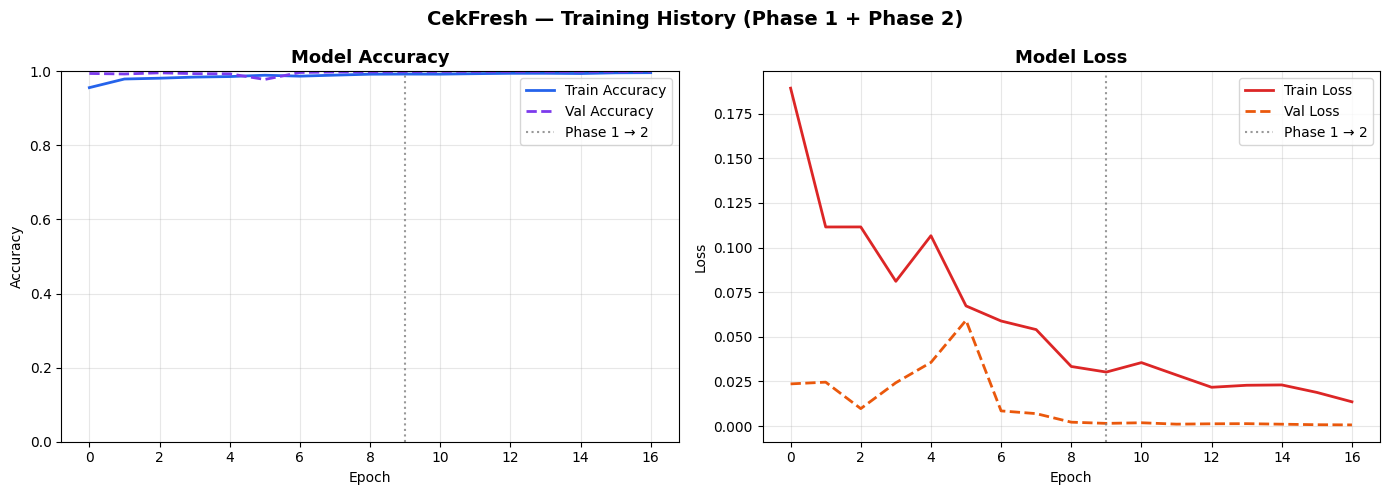

✅ Grafik disimpan: accuracy_loss_curve.png


In [26]:
import matplotlib.pyplot as plt

# Gabungkan history Phase 1 + Phase 2
history_all = {}
for key in history_p1.history:
    history_all[key] = history_p1.history[key] + history_p2.history[key]

phase1_end = len(history_p1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# -- Accuracy --
ax1.plot(history_all['accuracy'],     label='Train Accuracy', color='#2563eb', linewidth=2)
ax1.plot(history_all['val_accuracy'], label='Val Accuracy',   color='#7c3aed', linewidth=2, linestyle='--')
ax1.axvline(x=phase1_end - 1, color='gray', linestyle=':', alpha=0.8, label='Phase 1 → 2')
ax1.set_title('Model Accuracy', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim([0, 1])

# -- Loss --
ax2.plot(history_all['loss'],     label='Train Loss', color='#dc2626', linewidth=2)
ax2.plot(history_all['val_loss'], label='Val Loss',   color='#ea580c', linewidth=2, linestyle='--')
ax2.axvline(x=phase1_end - 1, color='gray', linestyle=':', alpha=0.8, label='Phase 1 → 2')
ax2.set_title('Model Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('CekFresh — Training History (Phase 1 + Phase 2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/accuracy_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan: accuracy_loss_curve.png")

### Evaluasi Model pada Test Set

Mengevaluasi performa model pada data test yang belum pernah dilihat model selama training. Menampilkan classification report dan confusion matrix.

Mengevaluasi model pada test set...
61/61 ━━━━━━━━━━━━━━━━━━━━ 23s 194ms/step

  TEST ACCURACY  : 0.9985  (99.85%)

Classification Report:
              precision    recall  f1-score   support

 freshbanana       1.00      1.00      1.00       381
 freshorange       1.00      1.00      1.00       388
 freshtomato       1.00      1.00      1.00       125
rottenbanana       1.00      1.00      1.00       530
rottenorange       0.99      1.00      1.00       403
rottentomato       1.00      0.98      0.99       125

    accuracy                           1.00      1952
   macro avg       1.00      1.00      1.00      1952
weighted avg       1.00      1.00      1.00      1952

✅ Classification report disimpan


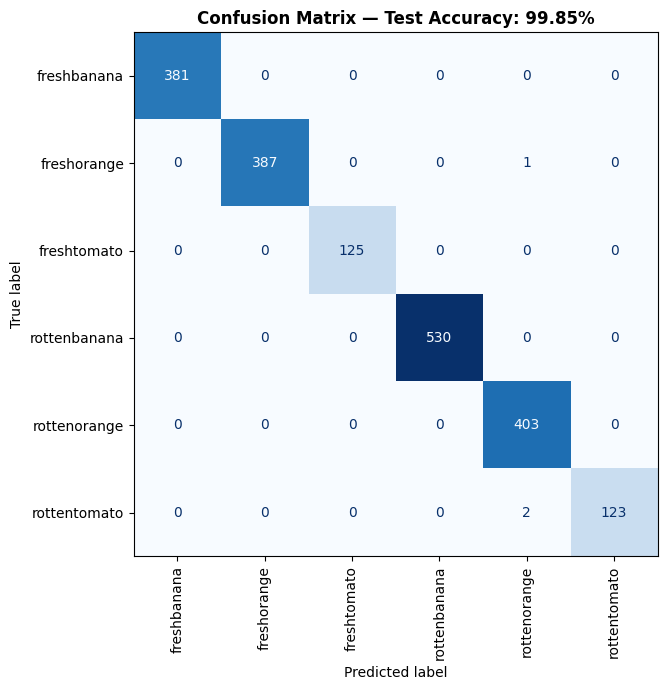

✅ Confusion matrix disimpan

  FILE TERSIMPAN DI GOOGLE DRIVE:
  /content/drive/MyDrive/CekFresh_Model/
    ├── cekfresh_model.keras
    ├── class_names.json
    ├── accuracy_loss_curve.png
    ├── confusion_matrix.png
    └── classification_report.txt


In [27]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)
import numpy as np
import matplotlib.pyplot as plt

print("Mengevaluasi model pada test set...")
test_generator.reset()

y_pred_prob = model.predict(test_generator, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)   # multiclass: ambil index terbesar
y_true      = test_generator.classes

# Accuracy
test_acc = accuracy_score(y_true, y_pred)
print(f"\n{'='*55}")
print(f"  TEST ACCURACY  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"{'='*55}")

# Label names
class_labels = [name for name, _ in sorted(
    train_generator.class_indices.items(), key=lambda x: x[1])]

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_labels)
print("\nClassification Report:")
print(report)

# Simpan report
with open(f'{SAVE_DIR}/classification_report.txt', 'w') as f:
    f.write(f"CekFresh Multiclass — Classification Report\n")
    f.write(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)\n\n")
    f.write(report)
print("✅ Classification report disimpan")

# Confusion Matrix
cm   = confusion_matrix(y_true, y_pred)
fig2, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation='vertical')
ax.set_title(f'Confusion Matrix — Test Accuracy: {test_acc*100:.2f}%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix disimpan")

print(f"\n{'='*55}")
print("  FILE TERSIMPAN DI GOOGLE DRIVE:")
print(f"  {SAVE_DIR}/")
print("    ├── cekfresh_model.keras")
print("    ├── class_names.json")
print("    ├── accuracy_loss_curve.png")
print("    ├── confusion_matrix.png")
print("    └── classification_report.txt")
print(f"{'='*55}")
